#Imports

In [ ]:
#pip install

In [ ]:
import gdown
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats
import plotly.io as pio

#Sprint 1: Tratamento e Limpeza de Dados

In [ ]:
file_id = '1khfn9mAHWRGaps487PJPF3KLYXnj9Eqf'
output_path = 'samsung_global_sales_dataset.csv'

gdown.download(id=file_id, output=output_path, quiet=False)

print(f'File downloaded to {output_path}')

df = pd.read_csv(output_path)

Downloading...
From: https://drive.google.com/uc?id=1khfn9mAHWRGaps487PJPF3KLYXnj9Eqf
To: /content/samsung_global_sales_dataset.csv
100%|██████████| 3.50M/3.50M [00:00<00:00, 23.9MB/s]


File downloaded to samsung_global_sales_dataset.csv


In [ ]:
#Tratamento de Dados

print("Valores nulos por coluna:\n", df.isnull().sum())

df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].mean())
df = df.fillna("Desconhecido")

# Padronização: Garantir que categorias não tenham espaços extras ou erros de caixa
df['category'] = df['category'].str.strip().str.title()
df['region'] = df['region'].str.strip().str.upper()
df['product_name'] = df['product_name'].str.strip().str.title()

# Limpeza de colunas redundantes ou de baixo valor analítico
colunas_para_remover = ['currency', 'fx_rate_to_usd', 'revenue_local_currency', 'year', 'city', 'month']
df = df.drop(columns=[col for col in colunas_para_remover if col in df.columns])

print("Colunas removidas com sucesso! Novo formato do dataset:")
display(df.head())
print(f"\nColunas restantes: {df.columns.tolist()}")

Valores nulos por coluna:
 sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   7849
color                        0
is_5g                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        9373
customer_rating           4251
return_status                0
dtype: int64
Colunas removidas com sucesso! Novo formato do dataset:


,sale_id,sale_date,quarter,country,region,product_name,category,storage,color,is_5g,...,units_sold,discounted_price_usd,revenue_usd,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,Q1,Argentina,SOUTH AMERICA,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,1 TB,Graphite,No,...,1,1246.77,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,Desconhecido,3.200000,Kept
1,SAMS-00000002,2021-03-23,Q1,Argentina,SOUTH AMERICA,Samsung Galaxy S23,Galaxy S,1 TB,Titanium Violet,Yes,...,2,728.86,1457.72,Authorized Reseller,Net Banking,Government,55+,Feature Phone,3.743515,Kept
2,SAMS-00000003,2021-05-22,Q2,Argentina,SOUTH AMERICA,Samsung Galaxy A34 5G,Galaxy A,128 GB,Awesome Black,Yes,...,6,360.97,2165.82,Corporate / B2B,Gift Card,Individual,25–34,New User,3.500000,Kept
3,SAMS-00000004,2021-07-26,Q3,Argentina,SOUTH AMERICA,Samsung T55 27-Inch Fhd,Monitor,Desconhecido,Black,No,...,3,242.69,728.07,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,Desconhecido,4.000000,Kept
4,SAMS-00000005,2021-09-02,Q3,Argentina,SOUTH AMERICA,Samsung Galaxy Z Fold 4,Galaxy Z,256 GB,Cream,Yes,...,2,1562.98,3125.96,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.000000,Kept



Colunas restantes: ['sale_id', 'sale_date', 'quarter', 'country', 'region', 'product_name', 'category', 'storage', 'color', 'is_5g', 'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd', 'sales_channel', 'payment_method', 'customer_segment', 'customer_age_group', 'previous_device_os', 'customer_rating', 'return_status']


#Sprint 2: Análise de Dados

Gráficos para Análise Inicial

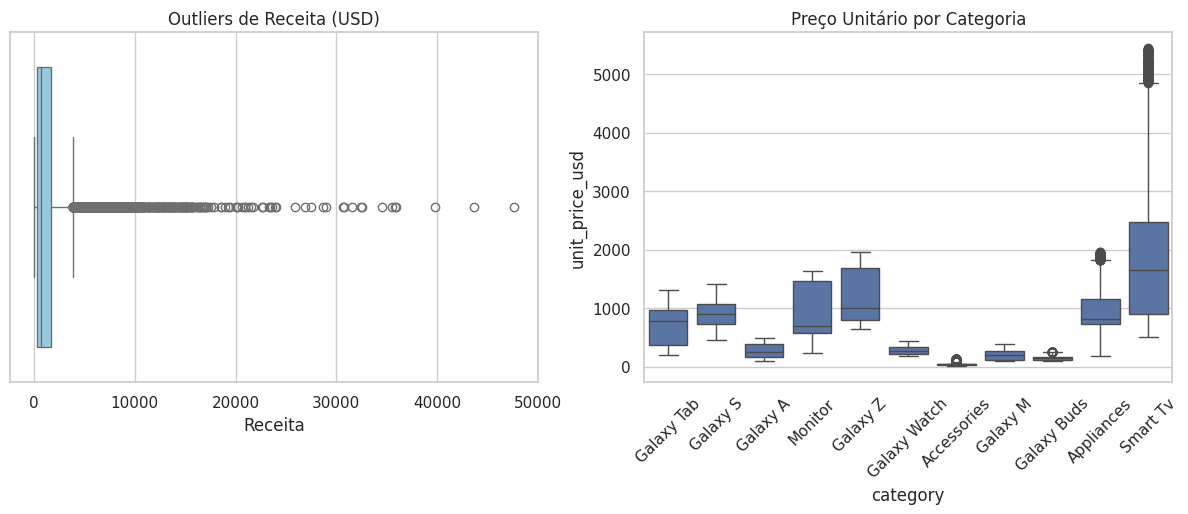

In [ ]:
pio.renderers.default = 'colab'

# Configuração de estilo
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# --- GRÁFICO 1: BOXPLOT ---
plt.subplot(2, 2, 1)
sns.boxplot(x=df['revenue_usd'], color="skyblue")
plt.title('Outliers de Receita (USD)')
plt.xlabel('Receita')

# --- GRÁFICO 2: BOXPLOT POR CATEGORIA ---
plt.subplot(2, 2, 2)
sns.boxplot(x='category', y='unit_price_usd', data=df)
plt.xticks(rotation=45)
plt.title('Preço Unitário por Categoria')

# --- BÔNUS: GRÁFICO INTERATIVO ---
fig = px.scatter(df, x="unit_price_usd", y="revenue_usd",
                 color="category", hover_data=['product_name', 'country'],
                 title="Mapa Interativo de Outliers (Passe o mouse)",
                 template="plotly_white")
fig.show()

<Figure size 1400x700 with 0 Axes>

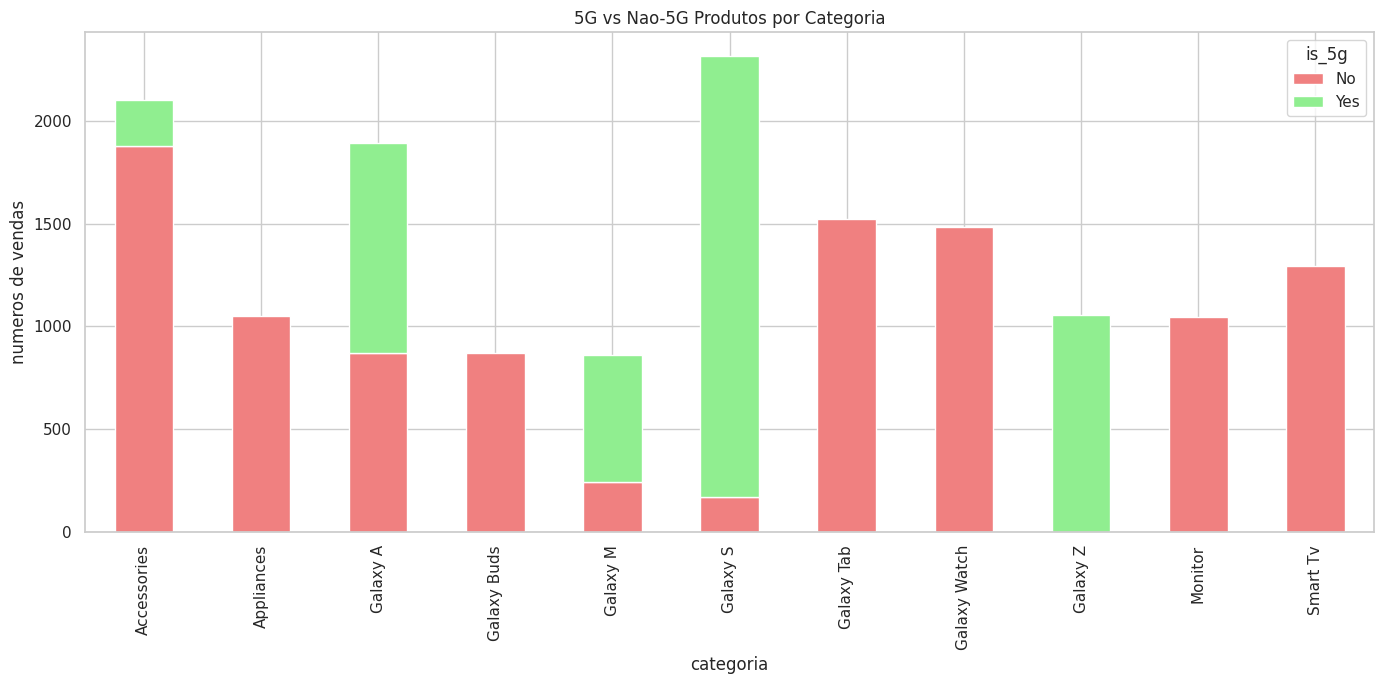

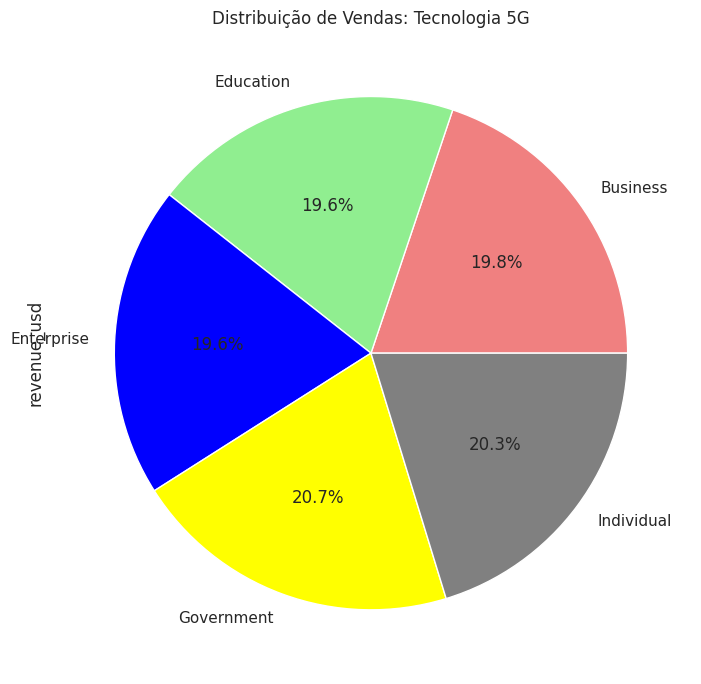

<Figure size 1200x600 with 0 Axes>

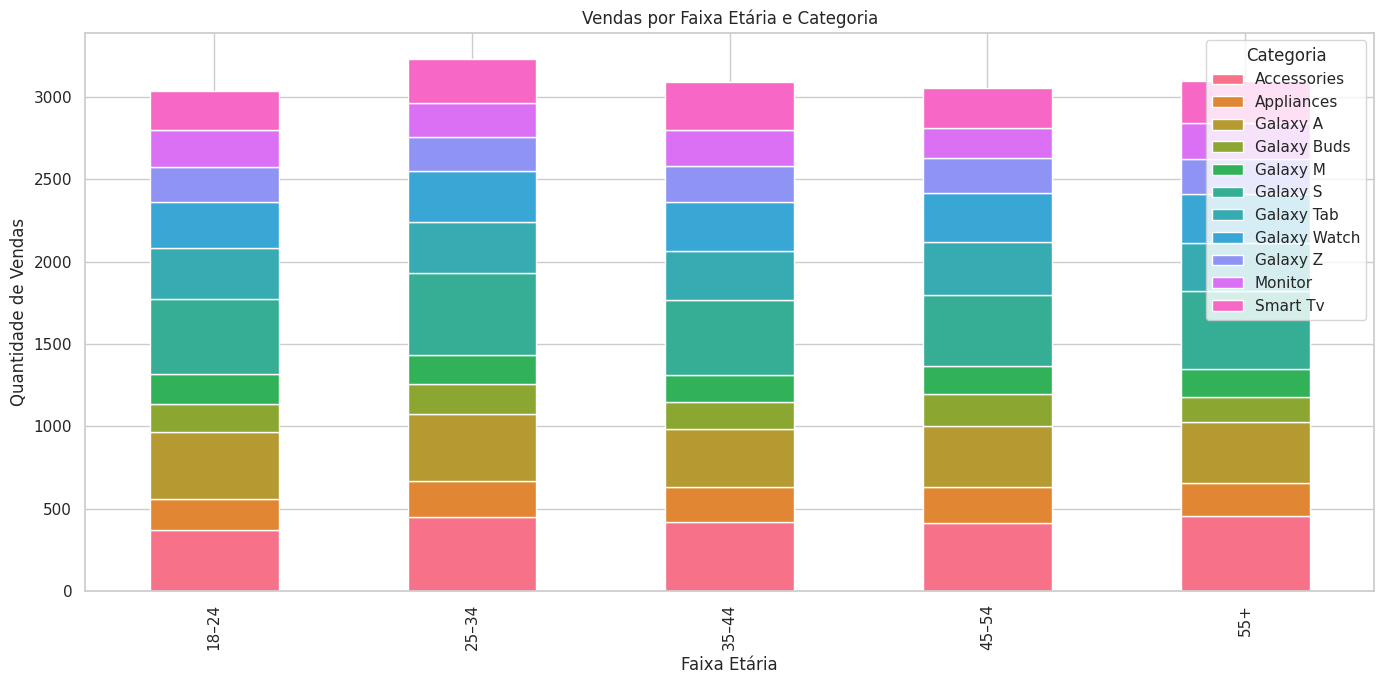

In [ ]:
# grafico 5G

category_5g_counts = df.groupby(['category', 'is_5g']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
category_5g_counts.plot(kind='bar', stacked=True, figsize=(14, 7), color=['lightcoral', 'lightgreen'])
plt.title('5G vs Nao-5G Produtos por Categoria')
plt.xlabel('categoria')
plt.ylabel('numeros de vendas')
plt.tight_layout()
plt.show()

# grafico sobre tipos de clientes
receita_cliente = df.groupby('customer_segment')['revenue_usd'].sum()

plt.figure(figsize=(14, 7))
receita_cliente.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightgreen', 'blue', 'yellow', 'grey'])
plt.title('Distribuição de Vendas: Tecnologia 5G')
plt.tight_layout()
plt.show()

# grafico preço da unidade X unidades vendidas

fig = px.scatter(df, x ="unit_price_usd", y = "units_sold", color="category",
                 hover_data =['category','product_name', 'unit_price_usd', 'units_sold'])


#grafico de vendas por faixas etarias x categorias
vendas_por_faixa_etaria = df.groupby(['customer_age_group', 'category']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 6))
paleta = sns.color_palette("husl", n_colors=11)
vendas_por_faixa_etaria.plot(kind='bar', stacked=True, figsize=(14, 7), color=paleta)
plt.title('Vendas por Faixa Etária e Categoria')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Vendas')
plt.legend(title='Categoria')

plt.tight_layout()
plt.show()

fig.show()

<Figure size 1400x700 with 0 Axes>

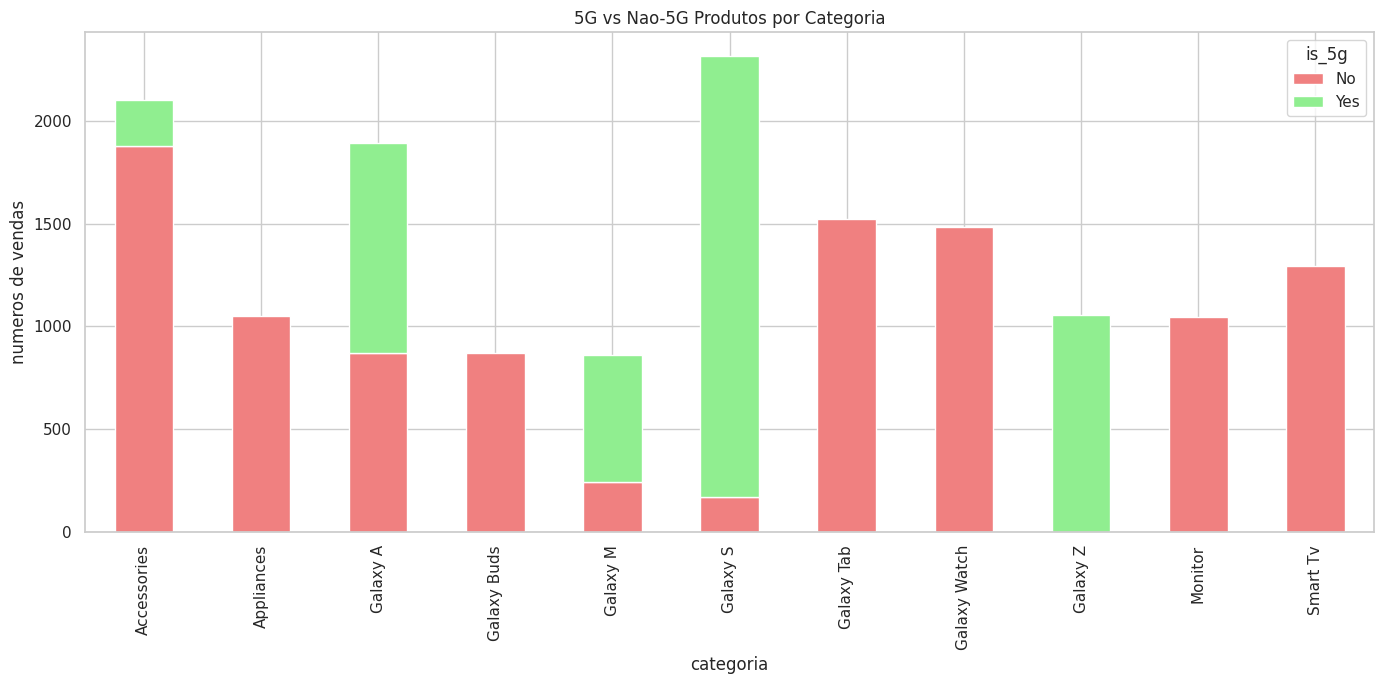

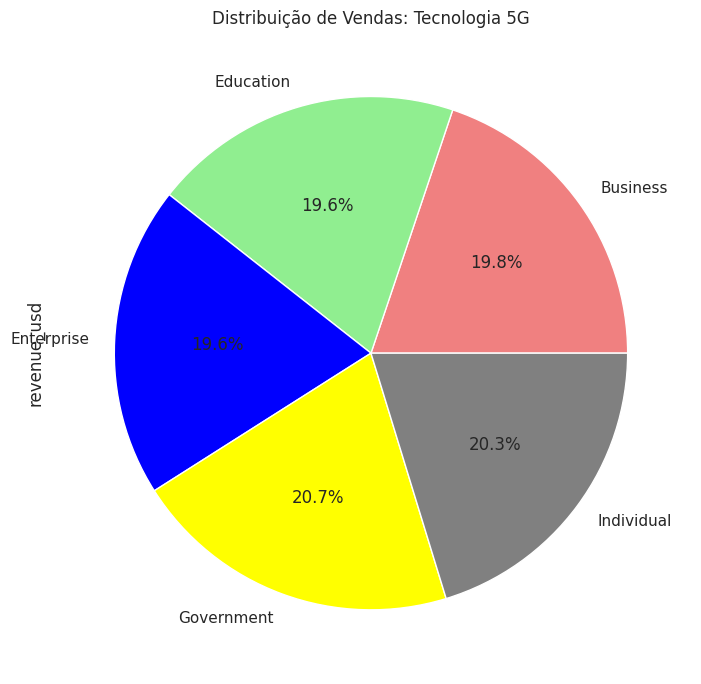

<Figure size 1200x600 with 0 Axes>

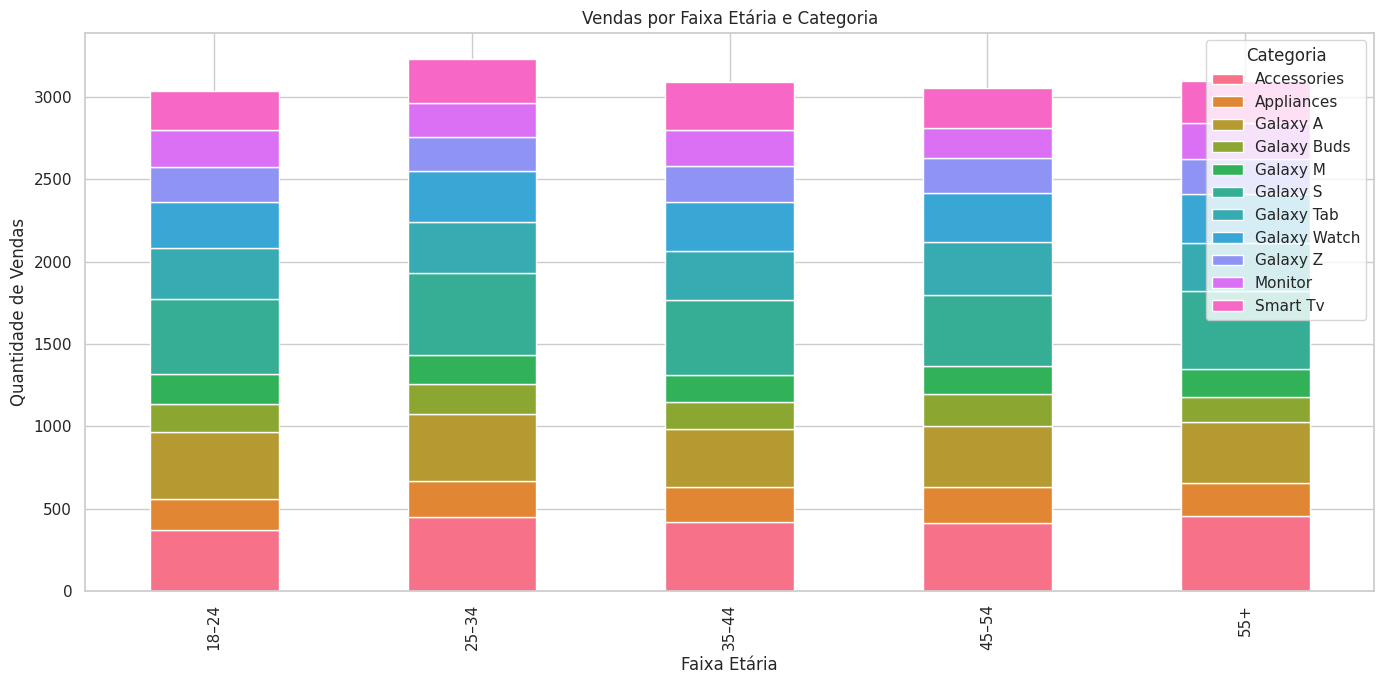

In [ ]:
# grafico 5G

category_5g_counts = df.groupby(['category', 'is_5g']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
category_5g_counts.plot(kind='bar', stacked=True, figsize=(14, 7), color=['lightcoral', 'lightgreen'])
plt.title('5G vs Nao-5G Produtos por Categoria')
plt.xlabel('categoria')
plt.ylabel('numeros de vendas')
plt.tight_layout()
plt.show()

# grafico sobre tipos de clientes
receita_cliente = df.groupby('customer_segment')['revenue_usd'].sum()

plt.figure(figsize=(14, 7))
receita_cliente.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightgreen', 'blue', 'yellow', 'grey'])
plt.title('Distribuição de Vendas: Tecnologia 5G')
plt.tight_layout()
plt.show()

# grafico preço da unidade X unidades vendidas

fig = px.scatter(df, x ="unit_price_usd", y = "units_sold", color="category",
                 hover_data =['category','product_name', 'unit_price_usd', 'units_sold'])


#grafico de vendas por faixas etarias x categorias
vendas_por_faixa_etaria = df.groupby(['customer_age_group', 'category']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 6))
paleta = sns.color_palette("husl", n_colors=11)
vendas_por_faixa_etaria.plot(kind='bar', stacked=True, figsize=(14, 7), color=paleta)
plt.title('Vendas por Faixa Etária e Categoria')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Vendas')
plt.legend(title='Categoria')

plt.tight_layout()
plt.show()

fig.show()

<Figure size 1400x700 with 0 Axes>

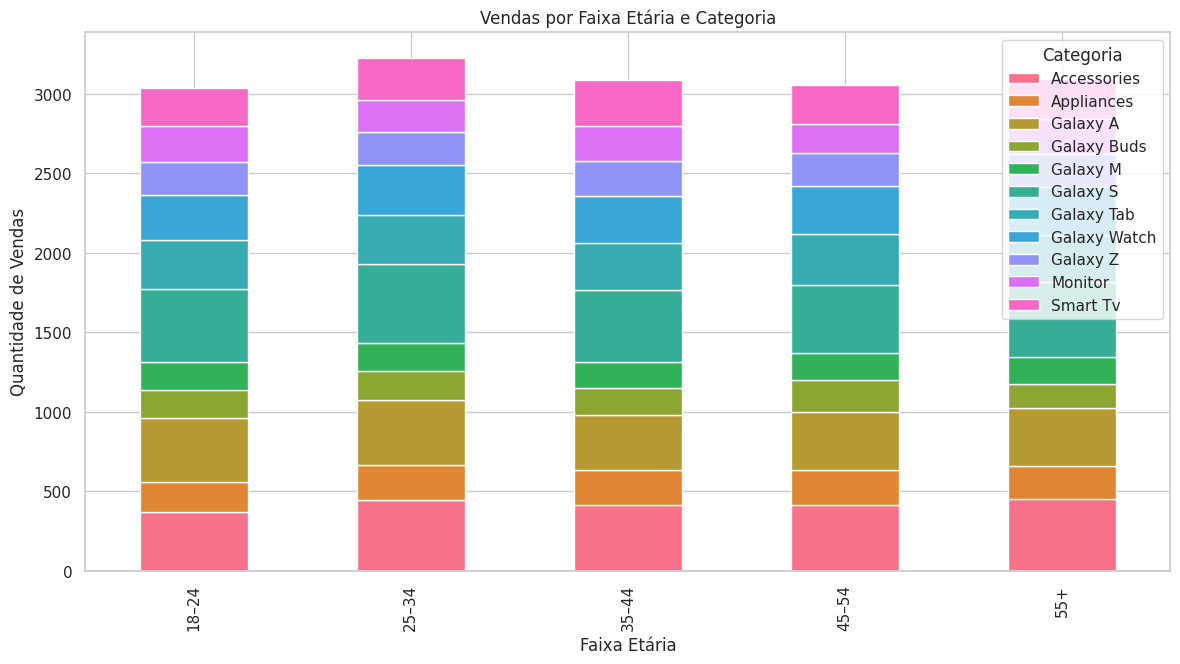

In [ ]:

#grafico de vendas por faixas etarias x categorias
vendas_por_faixa_etaria = df.groupby(['customer_age_group', 'category']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 7))
paleta = sns.color_palette("husl", n_colors=11)
vendas_por_faixa_etaria.plot(kind='bar', stacked=True, figsize=(14, 7), color=paleta)
plt.title('Vendas por Faixa Etária e Categoria')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Vendas')
plt.legend(title='Categoria')

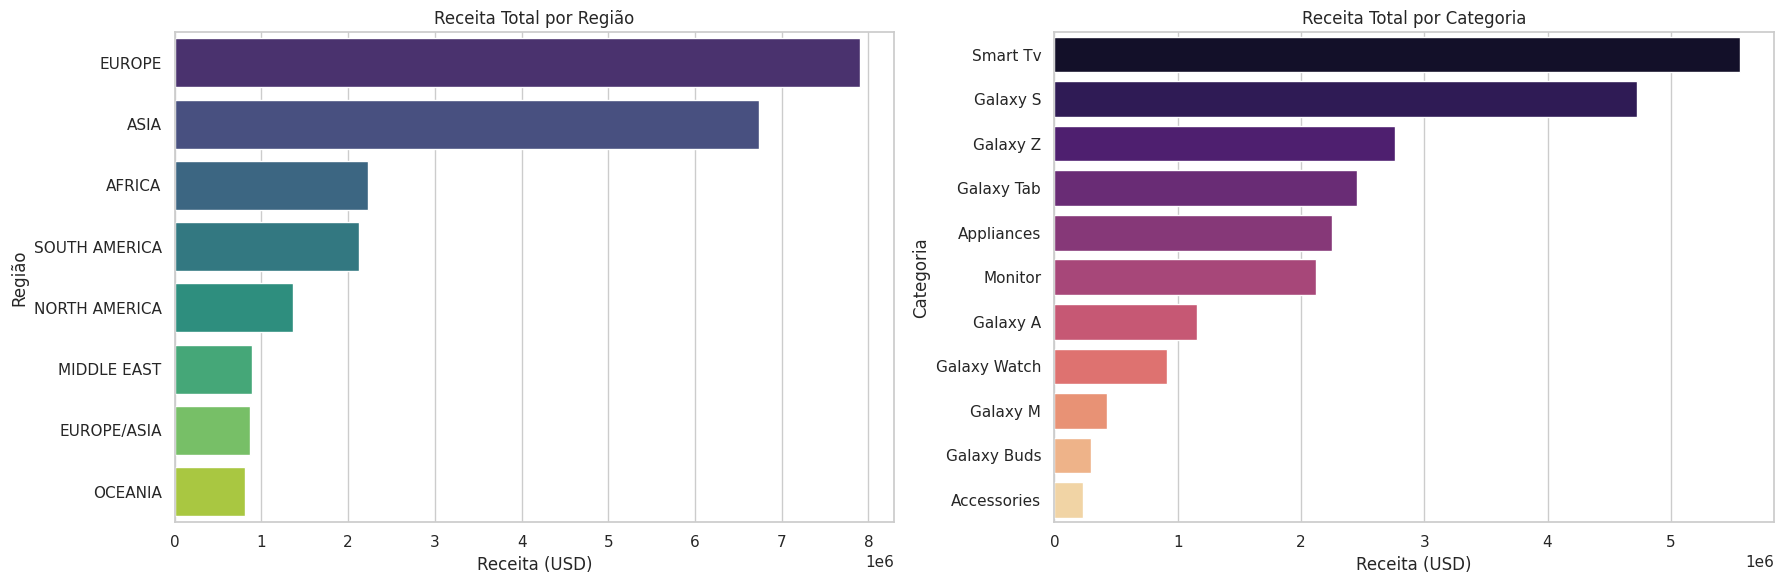

In [ ]:
# --- ANÁLISE: RECEITA POR REGIÃO E CATEGORIA ---
plt.figure(figsize=(18, 6))

# Subplot 1: Receita por Região
plt.subplot(1, 2, 1)
receita_regiao = df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False)
sns.barplot(x=receita_regiao.values, y=receita_regiao.index, palette='viridis', hue=receita_regiao.index, legend=False)
plt.title('Receita Total por Região')
plt.xlabel('Receita (USD)')
plt.ylabel('Região')

# Subplot 2: Receita por Categoria
plt.subplot(1, 2, 2)
receita_categoria = df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)
sns.barplot(x=receita_categoria.values, y=receita_categoria.index, palette='magma', hue=receita_categoria.index, legend=False)
plt.title('Receita Total por Categoria')
plt.xlabel('Receita (USD)')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()

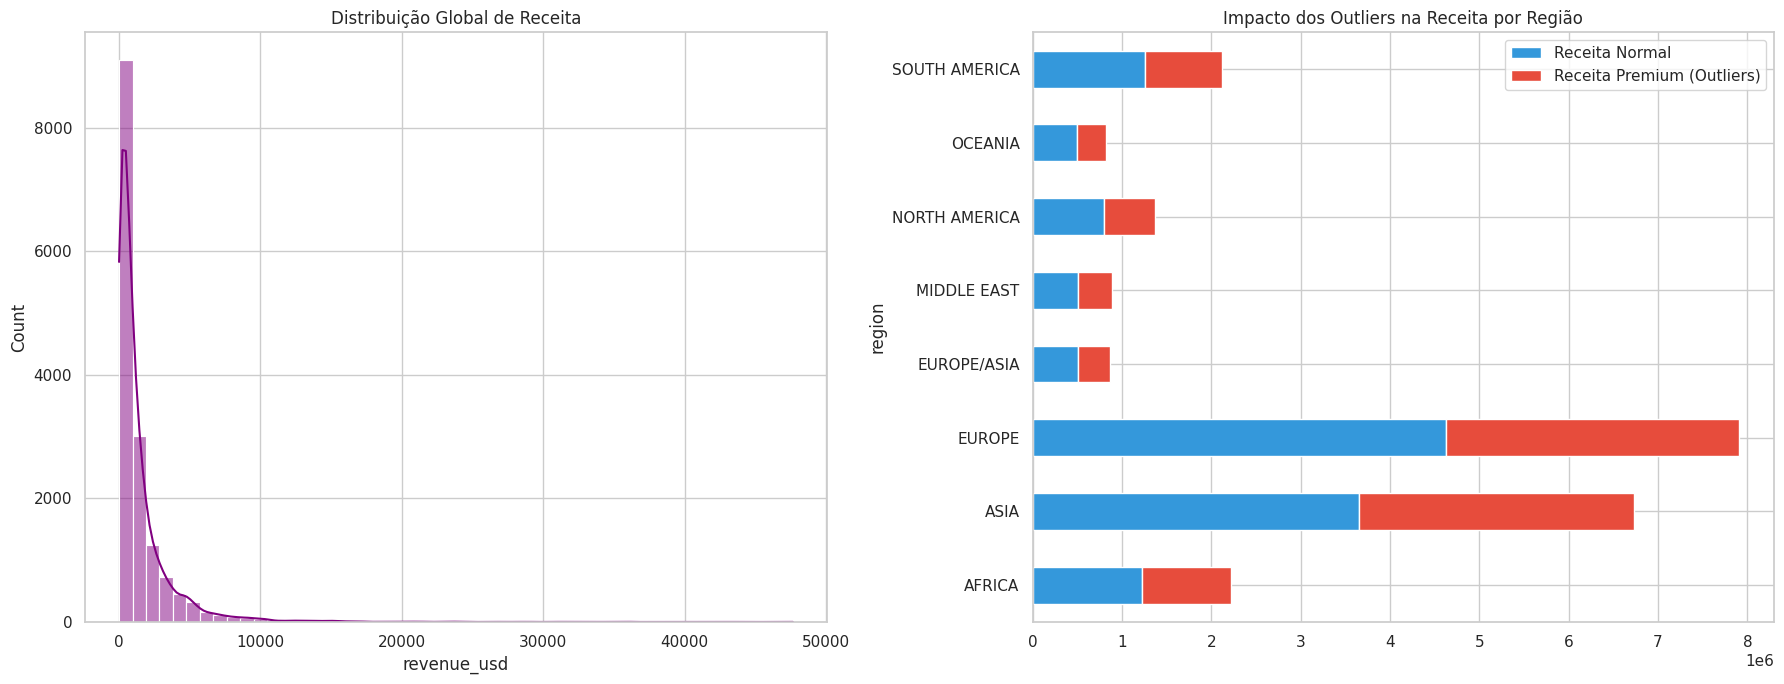

In [ ]:
# --- ANÁLISE: DISTRIBUIÇÃO E IMPACTO DE OUTLIERS ---
# 1. Cálculo de Outliers (IQR)
Q1_rev = df['revenue_usd'].quantile(0.25)
Q3_rev = df['revenue_usd'].quantile(0.75)
IQR_rev = Q3_rev - Q1_rev
limite_sup = Q3_rev + 1.5 * IQR_rev

df_normal = df[df['revenue_usd'] <= limite_sup]
df_outliers = df[df['revenue_usd'] > limite_sup]

analise_outliers = pd.DataFrame({
    'Receita Normal': df_normal.groupby('region')['revenue_usd'].sum(),
    'Receita Premium (Outliers)': df_outliers.groupby('region')['revenue_usd'].sum()
}).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 1: Distribuição (Histograma)
sns.histplot(df['revenue_usd'], bins=50, kde=True, ax=ax1, color='purple')
ax1.set_title('Distribuição Global de Receita')

# Subplot 2: Impacto por Região
analise_outliers[['Receita Normal', 'Receita Premium (Outliers)']].plot(kind='barh', stacked=True, ax=ax2, color=['#3498db', '#e74c3c'])
ax2.set_title('Impacto dos Outliers na Receita por Região')

plt.tight_layout()
plt.show()

In [ ]:
# Investigando quem são os outliers de receita
detail_outliers = df_outliers.groupby('product_name').agg({
    'unit_price_usd': 'mean',
    'sale_id': 'count',
    'revenue_usd': 'sum',
    'category' : 'first',
    'is_5g' : 'first',
}).sort_values(by='revenue_usd', ascending=False).rename(columns={'sale_id': 'quantidade_vendas', 'unit_price_usd': 'preco_medio_usd'})

print("Top 10 Produtos nos Outliers (Vendas Premium/B2B):")
display(detail_outliers.head(10))

Top 10 Produtos nos Outliers (Vendas Premium/B2B):


,preco_medio_usd,quantidade_vendas,revenue_usd,category,is_5g
product_name,,,,,
Samsung Neo Qled 8K Qn900C,5001.471950,200,2219631.26,Smart Tv,No
Samsung Oled S95C 65-Inch,2499.271587,126,969516.91,Smart Tv,No
Samsung French Door Refrigerator,1787.412192,73,565421.72,Appliances,No
Samsung Neo Qled 4K Qn85C,1797.642857,63,506631.83,Smart Tv,No
Samsung Galaxy Z Fold 4,1647.005970,67,493668.68,Galaxy Z,Yes
Samsung Galaxy Z Fold 5,1805.078154,65,491110.35,Galaxy Z,Yes
Samsung Viewfinity S9,1497.996825,63,427926.10,Monitor,No
Samsung Odyssey Neo G9,1510.653226,62,406987.14,Monitor,No
Samsung The Frame 55-Inch,1304.426522,46,293714.34,Smart Tv,No


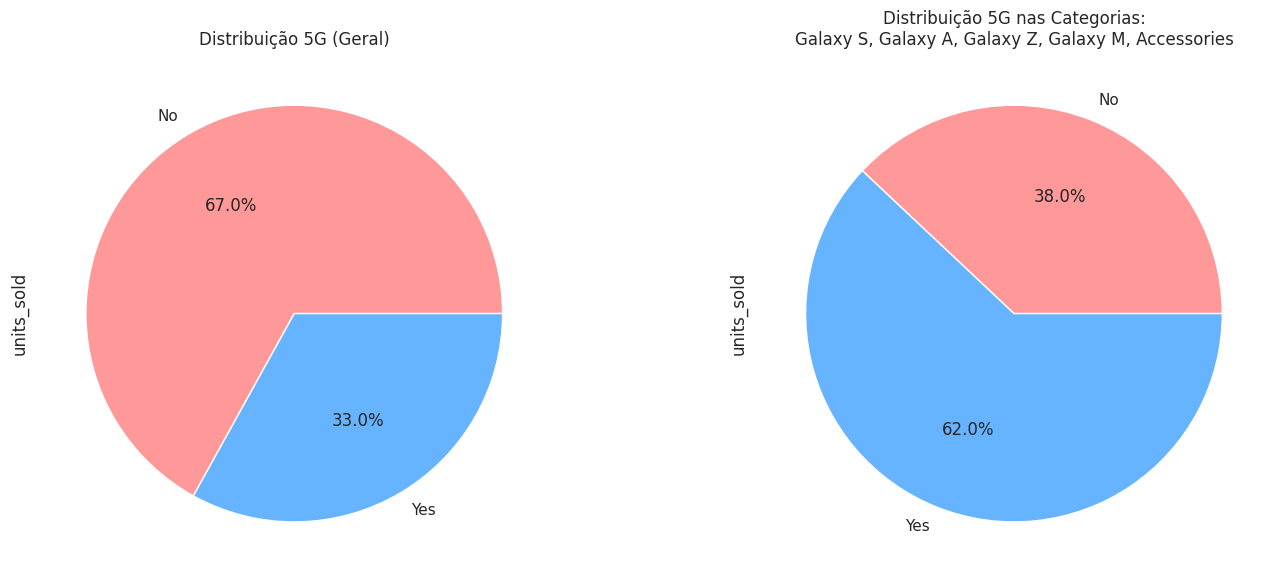

In [ ]:
# --- ANÁLISE: IMPACTO DO 5G ---
plt.figure(figsize=(15, 6))

# 1. Distribuição Geral de Unidades (5G vs Não 5G)
plt.subplot(1, 2, 1)
vendas_5g_geral = df.groupby('is_5g')['units_sold'].sum()
vendas_5g_geral.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Distribuição 5G (Geral)')

# 2. Distribuição em Categorias Compatíveis
plt.subplot(1, 2, 2)
categorias_5g = df[df['is_5g'] == 'Yes']['category'].unique()
df_filt_5g = df[df['category'].isin(categorias_5g)]
vendas_5g_cat = df_filt_5g.groupby('is_5g')['units_sold'].sum()
vendas_5g_cat.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title(f'Distribuição 5G nas Categorias:\n{ ", ".join(categorias_5g) }')

plt.tight_layout()
plt.show()

In [ ]:
#Análise com o p-value dos produtos por categorias

grupos = [df[df['category'] == cat]['units_sold'] for cat in df['category'].unique()]

# Executando a ANOVA
f_stat, p_value = stats.f_oneway(*grupos)

print(f"Estatística F: {f_stat:.4f}")
print(f"p-valor: {p_value:.4e}") # Formato científico para valores muito pequenos

# Interpretação
alpha = 0.05
if p_value < alpha:
    print("\nConclusão: Rejeitamos a hipótese nula.")
    print("A categoria do produto TEM relevância estatística no volume de vendas.")
else:
    print("\nConclusão: Não rejeitamos a hipótese nula.")
    print("Não há evidências de que a categoria influencie as vendas.")

Estatística F: 1.2054
p-valor: 2.8159e-01

Conclusão: Não rejeitamos a hipótese nula.
Não há evidências de que a categoria influencie as vendas.


### Análise do Total de Produtos Vendidos por Categoria (Teste Qui-Quadrado)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Recarregar o DataFrame e aplicar as transformações iniciais necessárias
# para garantir que a coluna 'category' exista.
# Nota: Esta é uma solução para este erro. O ideal seria realizar esta análise
# antes da etapa de One-Hot Encoding ou usar uma cópia do DataFrame.

# Reinicializar o df para o estado pré-one-hot encoding
output_path = 'samsung_global_sales_dataset.csv'
df_temp = pd.read_csv(output_path)

# Aplicar as mesmas etapas de limpeza que foram aplicadas ao df original
# para garantir consistência, mas sem o One-Hot Encoding.
df_temp['customer_rating'] = df_temp['customer_rating'].fillna(df_temp['customer_rating'].mean())
df_temp = df_temp.fillna("Desconhecido")
df_temp['category'] = df_temp['category'].str.strip().str.title()
df_temp['region'] = df_temp['region'].str.strip().str.upper()
df_temp['product_name'] = df_temp['product_name'].str.strip().str.title()
colunas_para_remover = ['currency', 'fx_rate_to_usd', 'revenue_local_currency', 'year', 'city', 'month']
df_temp = df_temp.drop(columns=[col for col in colunas_para_remover if col in df_temp.columns])


# 1. Calcular o total de unidades vendidas por categoria
total_units_per_category = df_temp.groupby('category')['units_sold'].sum().sort_values(ascending=False)
display(total_units_per_category)

# 2. Preparar dados para o teste Qui-Quadrado
observado = total_units_per_category.values

# Hipótese Nula: As categorias contribuem igualmente para o total de vendas
total_geral_unidades = observado.sum()
num_categorias = len(observado)
esperado = np.full(num_categorias, total_geral_unidades / num_categorias)

# 3. Executar o teste Qui-Quadrado de aderência
chi2_stat, p_value_chi2 = stats.chisquare(f_obs=observado, f_exp=esperado)

print(f"\nEstatística Qui-Quadrado: {chi2_stat:.4f}")
print(f"p-valor (Qui-Quadrado): {p_value_chi2:.4e}")

# 4. Interpretação automática
alpha = 0.05
if p_value_chi2 < alpha:
    print("\nConclusão: Rejeitamos a hipótese nula.")
    print("A distribuição total de unidades vendidas por categoria É estatisticamente diferente de uma distribuição igualitária.")
else:
    print("\nConclusão: Não rejeitamos a hipótese nula.")
    print("Não há evidências de que a distribuição total de unidades vendidas por categoria seja estatisticamente diferente de uma distribuição igualitária (embora a inspeção visual possa sugerir diferenças).")

,units_sold
category,
Galaxy S,5567
Accessories,4875
Galaxy A,4498
Galaxy Tab,3706
Galaxy Watch,3453
Smart Tv,2941
Appliances,2508
Monitor,2486
Galaxy Z,2436



Estatística Qui-Quadrado: 4362.7181
p-valor (Qui-Quadrado): 0.0000e+00

Conclusão: Rejeitamos a hipótese nula.
A distribuição total de unidades vendidas por categoria É estatisticamente diferente de uma distribuição igualitária.


/tmp/ipykernel_1010/4264841078.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




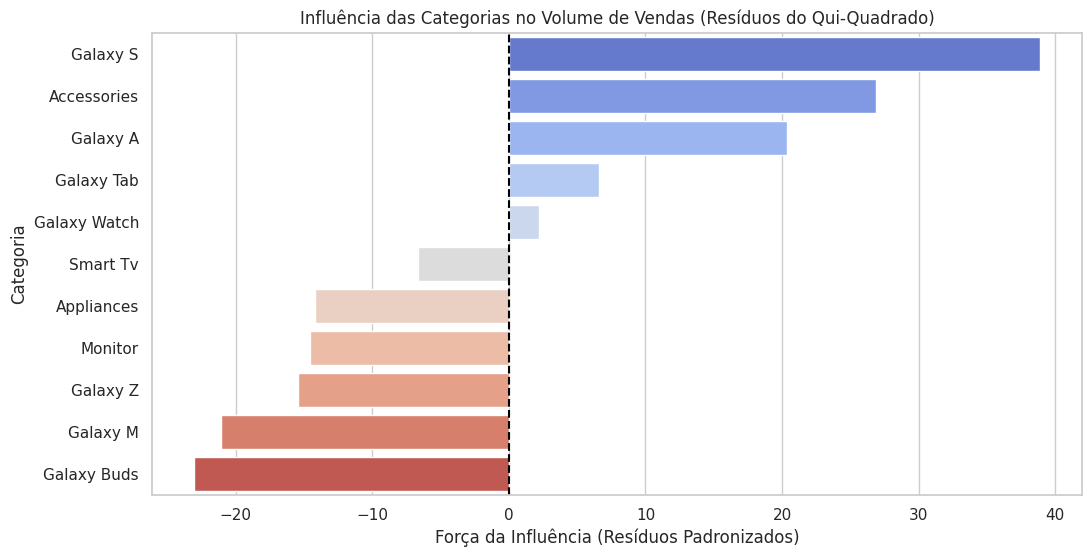

- Barras para a DIREITA (Azul/Positivo): Categorias que vendem ACIMA da média esperada.
- Barras para a ESQUERDA (Vermelho/Negativo): Categorias que vendem ABAIXO da média esperada.


In [ ]:
# 1. Calcular os resíduos: (Observado - Esperado) / sqrt(Esperado)
# Isso nos mostra o quão longe cada categoria está da 'média ideal'
residuos = (observado - esperado) / np.sqrt(esperado)

# 2. Criar um DataFrame para facilitar a visualização
df_residuos = pd.DataFrame({
    'Categoria': total_units_per_category.index,
    'Resíduo_Padronizado': residuos
}).sort_values(by='Resíduo_Padronizado', ascending=False)

# 3. Plotar o gráfico de influência
plt.figure(figsize=(12, 6))
sns.barplot(data=df_residuos, x='Resíduo_Padronizado', y='Categoria', palette='coolwarm')

# Adicionar uma linha no zero para referência
plt.axvline(x=0, color='black', linestyle='--')

plt.title('Influência das Categorias no Volume de Vendas (Resíduos do Qui-Quadrado)')
plt.xlabel('Força da Influência (Resíduos Padronizados)')
plt.ylabel('Categoria')
plt.show()

print("- Barras para a DIREITA (Azul/Positivo): Categorias que vendem ACIMA da média esperada.")
print("- Barras para a ESQUERDA (Vermelho/Negativo): Categorias que vendem ABAIXO da média esperada.")

### Feature Engineering

Para que o modelo possa usar as colunas não-numéricas, precisamos convertê-las. Vamos extrair informações numéricas da coluna `sale_date` e aplicar One-Hot Encoding às demais colunas categóricas. Também converteremos a coluna `is_5g` de 'Yes'/'No' para 1/0.

In [ ]:
# 1. Converter 'sale_date' para datetime e extrair features
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['day_of_week'] = df['sale_date'].dt.dayofweek # 0=Monday, 6=Sunday
df['month'] = df['sale_date'].dt.month
df['day_of_month'] = df['sale_date'].dt.day
df['quarter_num'] = df['sale_date'].dt.quarter # Numerical quarter

# Descartar a coluna 'sale_date' original, pois já extraímos as informações relevantes
df = df.drop(columns=['sale_date'])

# 2. Converter 'is_5g' para numérico (0 ou 1)
df['is_5g'] = df['is_5g'].map({'No': 0, 'Yes': 1})

# 3. Identificar colunas categóricas para One-Hot Encoding
# Excluir 'sale_id' se for apenas um identificador e não uma feature preditiva
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'sale_id' in categorical_cols:
    categorical_cols.remove('sale_id')

print(f"Colunas categóricas para One-Hot Encoding: {categorical_cols}")

# 4. Aplicar One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Descartar 'sale_id' se ainda estiver presente e não for usado
if 'sale_id' in df.columns:
    df = df.drop(columns=['sale_id'])


print("\nDataFrame após Feature Engineering e One-Hot Encoding:")
display(df.head())
print(f"Novo shape do DataFrame: {df.shape}")

Colunas categóricas para One-Hot Encoding: ['quarter', 'country', 'region', 'product_name', 'category', 'storage', 'color', 'sales_channel', 'payment_method', 'customer_segment', 'customer_age_group', 'previous_device_os', 'return_status']

DataFrame após Feature Engineering e One-Hot Encoding:


,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,customer_rating,day_of_week,month,day_of_month,...,customer_age_group_35–44,customer_age_group_45–54,customer_age_group_55+,previous_device_os_Android (Samsung),previous_device_os_Desconhecido,previous_device_os_Feature Phone,previous_device_os_New User,previous_device_os_iOS,return_status_Kept,return_status_Returned
0,0,1246.77,0,1,1246.77,1246.77,3.200000,4,1,1,...,False,True,False,False,True,False,False,False,True,False
1,1,809.84,10,2,728.86,1457.72,3.743515,1,3,23,...,False,False,True,False,False,True,False,False,True,False
2,1,410.19,12,6,360.97,2165.82,3.500000,5,5,22,...,False,False,False,False,False,False,True,False,True,False
3,0,242.69,0,3,242.69,728.07,4.000000,0,7,26,...,False,False,True,False,True,False,False,False,True,False
4,1,1562.98,0,2,1562.98,3125.96,3.000000,3,9,2,...,False,False,True,False,False,False,False,False,True,False


Novo shape do DataFrame: (15500, 220)


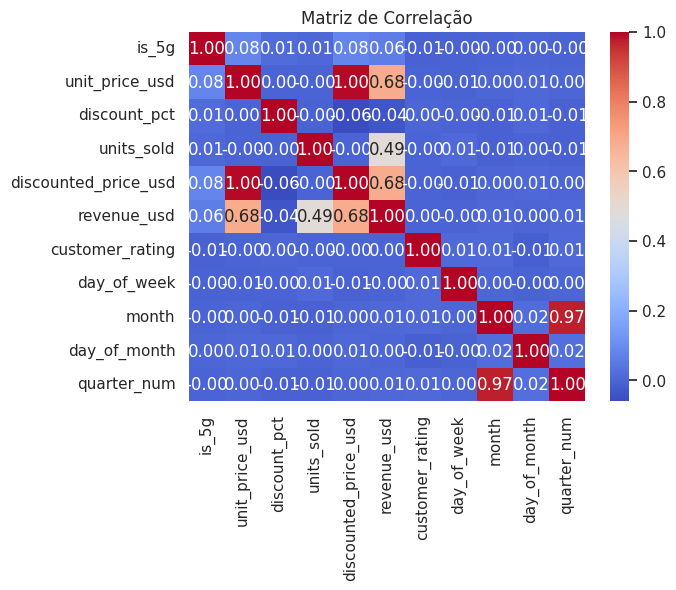

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ferramenta para dividir os dados em treino e teste
from sklearn.model_selection import train_test_split

# Modelos que vamos usar
from sklearn.linear_model import LinearRegression      # Modelo simples (baseline)
from sklearn.ensemble import RandomForestRegressor     # Modelo principal

# Métricas para medir o desempenho do modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Normalização dos dados
from sklearn.preprocessing import StandardScaler

##Matriz de correlação
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
correlacao = numeric_df.corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Matriz de Correlação')
plt.show()

In [ ]:
# X = as colunas que o modelo vai usar para aprender (features/variáveis de entrada)

# Definir as colunas desejadas
desired_features = ['unit_price_usd', 'is_5g']

# Adicionar colunas de categoria (one-hot encoded)
# Certifique-se de que 'df' está definido. Se não, as células anteriores não foram executadas.
if 'df' not in globals():
    raise RuntimeError("DataFrame 'df' is not defined. Please execute all preceding cells to load and preprocess the data.")

category_cols = [col for col in df.columns if col.startswith('category_')]
desired_features.extend(category_cols)

# Adicionar colunas de região (one-hot encoded)
region_cols = [col for col in df.columns if col.startswith('region_')]
desired_features.extend(region_cols)

# Filtrar o DataFrame para incluir apenas as colunas desejadas para X
X = df[desired_features]

# y = a coluna que o modelo vai tentar prever (target/variável de saída)
y = df['units_sold'].dropna()


print(f'Features usadas: {X.columns.tolist()}')
print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')

Features usadas: ['unit_price_usd', 'is_5g', 'category_Appliances', 'category_Galaxy A', 'category_Galaxy Buds', 'category_Galaxy M', 'category_Galaxy S', 'category_Galaxy Tab', 'category_Galaxy Watch', 'category_Galaxy Z', 'category_Monitor', 'category_Smart Tv', 'region_ASIA', 'region_EUROPE', 'region_EUROPE/ASIA', 'region_MIDDLE EAST', 'region_NORTH AMERICA', 'region_OCEANIA', 'region_SOUTH AMERICA']
Shape de X: (15500, 19)
Shape de y: (15500,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Dados de treino: {X_train.shape}')  # o modelo aprende com esses
print(f'Dados de teste:  {X_test.shape}')   # o modelo é avaliado com esses

Dados de treino: (12400, 19)
Dados de teste:  (3100, 19)


In [ ]:
scaler = StandardScaler()

# Selecionar apenas as colunas numéricas para o scaling
# Isso é importante porque o StandardScaler só funciona com dados numéricos
numeric_cols_train = X_train.select_dtypes(include=['number']).columns
X_train_numeric = X_train[numeric_cols_train]
X_test_numeric = X_test[numeric_cols_train]

# fit_transform: aprende a escala COM os dados de treino e já transforma
X_train_scaled = scaler.fit_transform(X_train_numeric)

# transform: usa a escala APRENDIDA no treino para transformar o teste
# (nunca usamos o teste para aprender nada!)
X_test_scaled = scaler.transform(X_test_numeric)

print(f'Shape de X_train_scaled: {X_train_scaled.shape}')
print(f'Shape de X_test_scaled: {X_test_scaled.shape}')
print(df.dtypes)

Shape de X_train_scaled: (12400, 2)
Shape de X_test_scaled: (3100, 2)
is_5g                                 int64
unit_price_usd                      float64
discount_pct                          int64
units_sold                            int64
discounted_price_usd                float64
                                     ...   
previous_device_os_Feature Phone       bool
previous_device_os_New User            bool
previous_device_os_iOS                 bool
return_status_Kept                     bool
return_status_Returned                 bool
Length: 220, dtype: object


In [ ]:
# Criação do modelo de Regressão Linear

modeloLn = LinearRegression()

# O modelo aprende a relação entre X e y nos dados de treino
modeloLn.fit(X_train_scaled, y_train)

# O modelo faz previsões para os dados de teste
y_pred_lr = modeloLn.predict(X_test_scaled)

# Calculando as métricas de desempenho
mae_lr  = mean_absolute_error(y_test, y_pred_lr)   # erro médio em dólares
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5  # penaliza erros grandes
r2_lr   = r2_score(y_test, y_pred_lr)              # % da variação explicada (0 a 1)

print('=== Regressão Linear (Baseline) ===')
print(f'MAE:  {mae_lr:.2f}')
print(f'RMSE: {rmse_lr:.2f}')
print(f'R²:   {r2_lr:.4f}')

=== Regressão Linear (Baseline) ===
MAE:  1.37
RMSE: 1.86
R²:   -0.0019


In [ ]:
# Criação do modelo de Random Forest

# n_estimators=100: quantidade de árvores de decisão criadas
# random_state=42:  garante resultados reproduzíveis
# n_jobs=-1:        usa todos os núcleos do processador (mais rápido)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Treinando o modelo (aqui não precisamos dos dados normalizados)
rf.fit(X_train, y_train)

# Fazendo previsões
y_pred_rf = rf.predict(X_test)

# Calculando as métricas
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Random Forest ===')
print(f'MAE:  {mae_rf:.2f}')
print(f'RMSE: {rmse_rf:.2f}')
print(f'R²:   {r2_rf:.4f}')

=== Random Forest ===
MAE:  1.55
RMSE: 2.15
R²:   -0.3422


In [ ]:
# Comparando os dois modelos

# Criamos uma tabela para facilitar a comparação visual dos resultados
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest'],
    'MAE':    [mae_lr, mae_rf],   # quanto menor, melhor
    'RMSE':   [rmse_lr, rmse_rf], # quanto menor, melhor
    'R²':     [r2_lr, r2_rf]      # quanto maior (mais perto de 1), melhor
})

display(resultados)

,Modelo,MAE,RMSE,R²
0,Regressão Linear,1.374046,1.857706,-0.001905
1,Random Forest,1.553477,2.150140,-0.342166


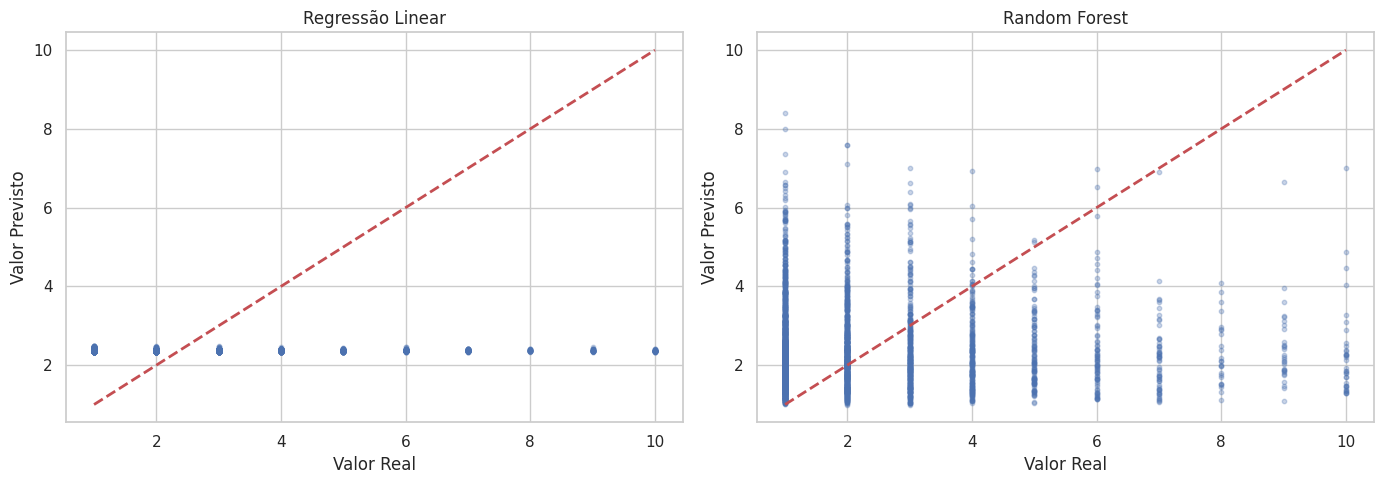

In [ ]:
# Gráfico de Valores Previstos vs Valores Reais

# Este gráfico mostra o quão próximas as previsões estão dos valores reais
# Se o modelo fosse perfeito, todos os pontos estariam sobre a linha vermelha

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Regressão Linear', 'Random Forest']
):
    # Cada ponto = uma casa: eixo X é o valor real, eixo Y é o valor previsto
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)

    # Linha vermelha = previsão perfeita (previsto == real)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', lw=2)

    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Valor Previsto')
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

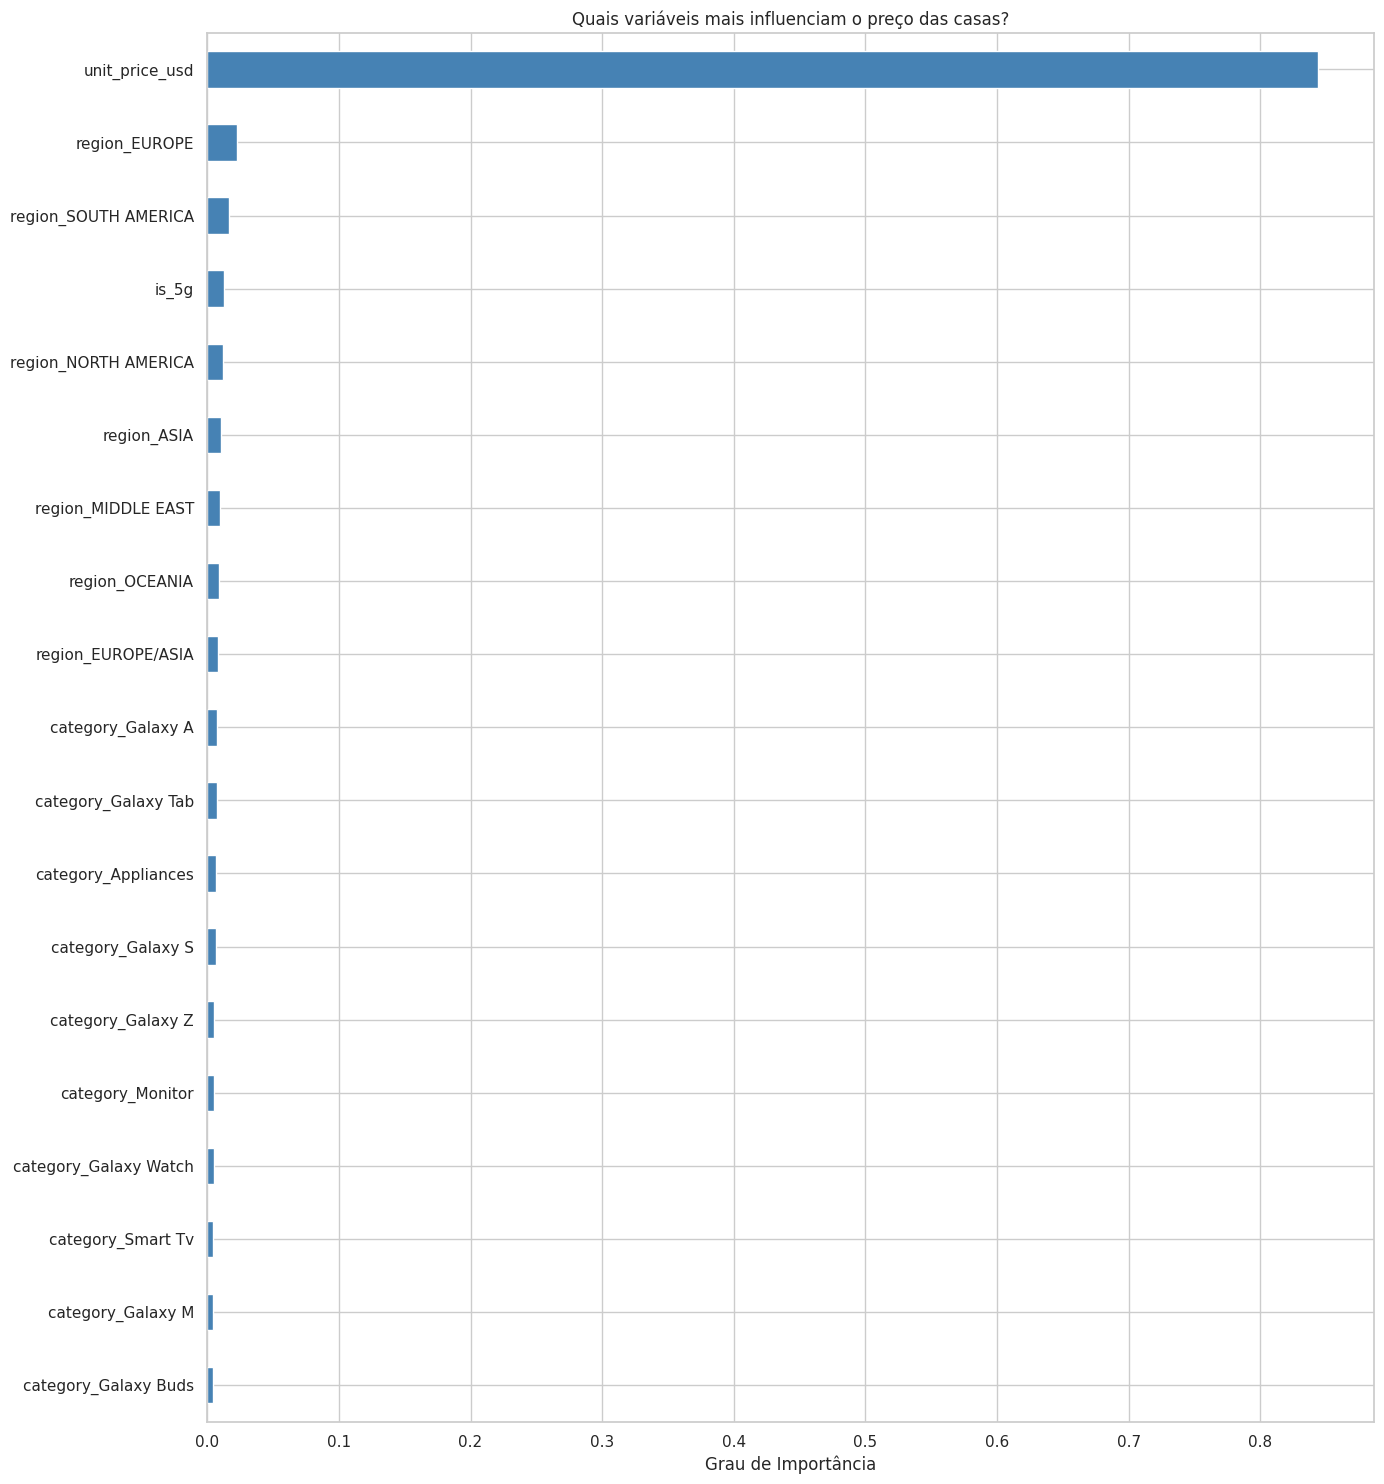

,0
category_Galaxy Buds,0.004043
category_Galaxy M,0.004214
category_Smart Tv,0.004241
category_Galaxy Watch,0.004916
category_Monitor,0.005076
category_Galaxy Z,0.005228
category_Galaxy S,0.006317
category_Appliances,0.006520
category_Galaxy Tab,0.007118
category_Galaxy A,0.007604


In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)

# Ordenamos do menor para o maior para facilitar a leitura no gráfico
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(14, 15))
importancias.plot(kind='barh', color='steelblue')
plt.title('Quais variáveis mais influenciam o preço das casas?')
plt.xlabel('Grau de Importância')
plt.tight_layout()
plt.show()
display(importancias)

# Quanto maior a barra, mais essa variável ajudou o modelo a prever o preço